In [1]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

In [2]:
# Load averaged results
date_one_to_one_gaussian = "03060920"
with open(f"../Results_averaged/mixing_capacity_qrc_gaussian_results_{date_one_to_one_gaussian}_averaged.pkl", "rb") as f:
    data_one_to_one_gaussian = pickle.load(f)

date_fill_gaussian = "03061219"
with open(f"../Results_averaged/mixing_capacity_qrc_gaussian_results_{date_fill_gaussian}_averaged.pkl", "rb") as f:
    data_fill_gaussian = pickle.load(f)

date_dense_gaussian = "03061220"
with open(f"../Results_averaged/mixing_capacity_qrc_gaussian_results_{date_dense_gaussian}_averaged.pkl", "rb") as f:
    data_dense_gaussian = pickle.load(f)

date_one_to_one_spin = "03080810"
with open(f"../Results_averaged/mixing_capacity_qrc_tilted_tfim_results_{date_one_to_one_spin}_averaged.pkl", "rb") as f:
    data_one_to_one_spin = pickle.load(f)

date_fill_spin = "03080816"
with open(f"../Results_averaged/mixing_capacity_qrc_tilted_tfim_results_{date_fill_spin}_averaged.pkl", "rb") as f:
    data_fill_spin = pickle.load(f)

date_dense_spin = "03080818"
with open(f"../Results_averaged/mixing_capacity_qrc_tilted_tfim_results_{date_dense_spin}_averaged.pkl", "rb") as f:
    data_dense_spin = pickle.load(f)

In [3]:
df2_one_to_one_gaussian = pd.DataFrame(data_one_to_one_gaussian)
df2_fill_gaussian = pd.DataFrame(data_fill_gaussian)
df2_dense_gaussian = pd.DataFrame(data_dense_gaussian)

df2_one_to_one_spin = pd.DataFrame(data_one_to_one_spin)
df2_fill_spin = pd.DataFrame(data_fill_spin)
df2_dense_spin = pd.DataFrame(data_dense_spin)


--- Processing Metric: first_moment_2 ---
Max first_moment_2_mean for DV-QRC (Local): 3.9001
Max first_moment_2_mean for DV-QRC (Clustered): 4.0727
Max first_moment_2_mean for DV-QRC (Global): 4.3503
Max first_moment_2_mean for CV-QRC (Local): 6.3457
Max first_moment_2_mean for CV-QRC (Clustered): 4.9017
Max first_moment_2_mean for CV-QRC (Global): 5.3728


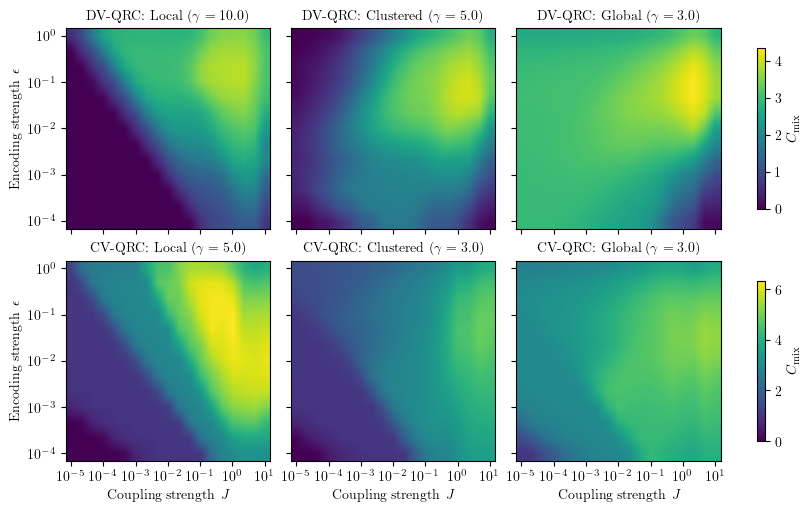

In [4]:
import numpy as np
import matplotlib.pyplot as plt

models_data = [
    ("DV-QRC", [
        ("Local", df2_one_to_one_spin),
        ("Clustered", df2_fill_spin),
        ("Global", df2_dense_spin)
    ]),
    ("CV-QRC", [
        ("Local", df2_one_to_one_gaussian),
        ("Clustered", df2_fill_gaussian),
        ("Global", df2_dense_gaussian)
    ])
]

metrics = [
    ("first_moment_2_mean", "first_moment_2_std", "first_moment_2"),
    # ("negativity_mean", "negativity_std", "negativity"),
    # Add other metrics here as needed
]

threshold = None  # set to a float to filter weak grids

for mean_col, std_col, metric_label in metrics:
    
    # 1. Determine global coordinate grids across ALL DataFrames to ensure perfectly aligned axes
    all_enc_vals = set()
    all_cs_vals = set()
    
    for row_label, cols in models_data:
        for col_label, df in cols:
            if "encoding_strength" in df.columns:
                all_enc_vals.update(df["encoding_strength"].dropna().unique())
            if "coupling_strength" in df.columns:
                all_cs_vals.update(df["coupling_strength"].dropna().unique())

    # Sort the coordinates to ensure the grid is strictly ordered
    enc_vals = sorted(list(all_enc_vals))
    cs_vals = sorted(list(all_cs_vals))

    if not enc_vals or not cs_vals:
        print(f"\nNo valid coordinates found for metric: {metric_label}. Skipping.")
        continue

    # --- Calculate clean log ticks based on the global grid ---
    x_ticks = [idx for idx, val in enumerate(cs_vals) if np.isclose(np.log10(val), np.round(np.log10(val)), atol=1e-5)]
    x_labels = [f"$10^{{{int(np.round(np.log10(val)))}}}$" for idx, val in enumerate(cs_vals) if np.isclose(np.log10(val), np.round(np.log10(val)), atol=1e-5)]

    y_ticks = [idx for idx, val in enumerate(enc_vals) if np.isclose(np.log10(val), np.round(np.log10(val)), atol=1e-5)]
    y_labels = [f"$10^{{{int(np.round(np.log10(val)))}}}$" for idx, val in enumerate(enc_vals) if np.isclose(np.log10(val), np.round(np.log10(val)), atol=1e-5)]
    # ----------------------------------------------------------

    # 2. Set up the 2x3 Figure
    fig, axes = plt.subplots(
        nrows=2, 
        ncols=3,
        figsize=(8, 5),  # Made slightly wider to accommodate the two colorbars comfortably
        sharex=True,
        sharey=True,
        squeeze=False,
        constrained_layout=True 
    )

    print(f"\n--- Processing Metric: {metric_label} ---")

    # 3. Iterate through the models_data structure row by row
    for i, (row_label, cols) in enumerate(models_data):
        
        # Determine the C_mix multiplier based on the row label
        if row_label == "DV-QRC":
            multiplier = 18
        elif row_label == "CV-QRC":
            multiplier = 21
        else:
            multiplier = 1
            
        # Calculate row-specific minimums and maximums for the color scale
        row_vmin = float('inf')
        row_vmax = float('-inf')
        
        for col_label, df in cols:
            if mean_col in df.columns:
                # Apply the multiplier to the valid data to find the correct vmin/vmax
                valid_data = df[mean_col].dropna() * multiplier
                if not valid_data.empty:
                    row_vmin = min(row_vmin, valid_data.min())
                    row_vmax = max(row_vmax, valid_data.max())
                    
        # Fallback if a row is completely empty
        if row_vmin == float('inf'):
            row_vmin, row_vmax = 0, 1  
            
        row_im = None
        
        # Plot each column for the current row
        for j, (col_label, df) in enumerate(cols):
            ax = axes[i, j]
            
            # Create a copy of the dataframe to safely apply the multiplier for plotting
            plot_df = df.copy()
            if mean_col in plot_df.columns:
                plot_df[mean_col] = plot_df[mean_col] * multiplier
            
            # Print maximum values for this specific subplot (now using the multiplied data)
            if mean_col in plot_df.columns and not plot_df[mean_col].dropna().empty:
                max_idx = plot_df[mean_col].idxmax()
                max_row = plot_df.loc[max_idx]
                print(f"Max {mean_col} for {row_label} ({col_label}): {max_row[mean_col]:.4f}")
            
            # Extract the unique gamma value safely
            gamma_str = ""
            if "gamma" in plot_df.columns:
                unique_gammas = plot_df["gamma"].dropna().unique()
                if len(unique_gammas) > 0:
                    gamma_val = unique_gammas[0]
                    # Format gamma to append to the title
                    gamma_str = r" ($\gamma=" + str(gamma_val) + r"$)"
            
            # Combine original title logic with the extracted gamma
            full_title = f"{row_label}: {col_label}{gamma_str}"
            
            # Filter and pivot
            sub = plot_df.dropna(subset=[mean_col])
            
            if sub.empty or (threshold is not None and sub[mean_col].max() <= threshold):
                ax.text(0.5, 0.5, "no data\nor below threshold", ha="center", va="center",
                        transform=ax.transAxes, alpha=0.6)
                ax.set_title(full_title)
                continue

            pivot_df = sub.pivot_table(
                index="encoding_strength", 
                columns="coupling_strength", 
                values=mean_col,
                aggfunc="mean" 
            )
            
            # Reindex ensures identical shape and axis alignment
            pivot_df = pivot_df.reindex(index=enc_vals, columns=cs_vals)

            # Plot heatmap with row-specific vmin and vmax
            row_im = ax.imshow(
                pivot_df.values, 
                cmap="viridis", 
                aspect="auto", 
                origin="lower", 
                vmin=row_vmin,  
                vmax=row_vmax,  
                interpolation="bilinear" 
            )

            # Apply the filtered log ticks 
            ax.set_xticks(x_ticks)
            ax.set_xticklabels(x_labels)
            ax.set_yticks(y_ticks)
            ax.set_yticklabels(y_labels)

            # Set the updated title
            ax.set_title(full_title, fontsize=10)

            # Only label axes on the outer edges
            if i == len(models_data) - 1:
                ax.set_xlabel(r"Coupling strength $J$")
            if j == 0:
                ax.set_ylabel(r"Encoding strength $\epsilon$")

        # 4. Attach a colorbar to the current row
        if row_im is not None:
            # ax=axes[i, :] tells matplotlib to attach the colorbar to the entire row
            fig.colorbar(row_im, ax=axes[i, :], label=r"$C_\mathrm{mix}$", shrink=0.8, aspect=20)

    # fig.suptitle(f"Comparison: {metric_label}", fontsize=14, fontweight="bold")
    plt.savefig(f"../Plots/mixing_capacity_comparison_heatmap_{metric_label}.pdf")
    plt.show()